# Additional Feature Engineering for Rent Price Prediction
This notebook implements new features based on EDA suggestions (except geospatial features).
gineering steps to improve model performance for rent price prediction. We use insights from EDA and domain knowledge to create new features and transform existing ones.

## Imports and Setup

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.distance import geodesic
from tqdm import tqdm
tqdm.pandas()

plt.style.use('../styles/presentation.mplstyle')

COLOR_PLOT = 'tan'

geolocator = Nominatim(user_agent='my_request')
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.2)

%load_ext autoreload
%autoreload all
from src.utils.eda_utils import plot_numerical_vs_target

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [3]:
data = pd.read_csv('../data/processed/train_df.csv')
data.shape

(9140, 29)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9140 entries, 0 to 9139
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   9140 non-null   int64  
 1   price                9140 non-null   int64  
 2   address              9140 non-null   object 
 3   coordinates          9032 non-null   object 
 4   region               9140 non-null   object 
 5   subway               7375 non-null   object 
 6   rooms                9140 non-null   int64  
 7   footage              9140 non-null   object 
 8   floor                9140 non-null   int64  
 9   features             9140 non-null   object 
 10  residential          4367 non-null   object 
 11  neighborhood         9140 non-null   object 
 12  description          9140 non-null   object 
 13  detail               9140 non-null   object 
 14  attributes           5501 non-null   object 
 15  full_area            9140 non-null   f

## Numerical Feature Engineering

We create new features and transform existing numerical columns, such as floor, storeys, and area. This includes:
- Room density (area per room)
- Relative floor (floor/num_storeys)
- Binning/capping floor and storeys
- Special floor features (first, last, one-before-last floor)

### Room Density

In [5]:
data['room_density'] = data['full_area'] / data['rooms'].replace(0, np.nan)

### Relative floor

In [6]:
data['relative_floor'] = data['floor'] / data['num_storeys'].replace(0, np.nan)

### Binning Floor and Storeys
We bin and cap the `floor` and `num_storeys` features to reduce noise from rare high values and create interpretable categories.

In [7]:
data['floor_binned'] = pd.cut(
    data['floor'],
    bins=[0, 1, 5, 10, 15, 20, 25, np.inf],
    labels=['1', '2-5', '6-10', '11-15', '16-20', '21-25', '26+']
)

data['num_storeys_binned'] = pd.cut(
    data['num_storeys'],
    bins=[0, 5, 10, 15, 20, 30, np.inf],
    labels=['1-5', '6-10', '11-15', '16-20', '21-30', '31+']
)

### Special Floor Features

In [8]:
data['first_floor'] = (data['floor'] == 1).astype(int)
data['last_floor'] = (data['floor'] == data['num_storeys']).astype(int)
data['one_before_last_floor'] = (
    data['floor'] == (data['num_storeys'] - 1)
).astype(int)

### Visual Exploration

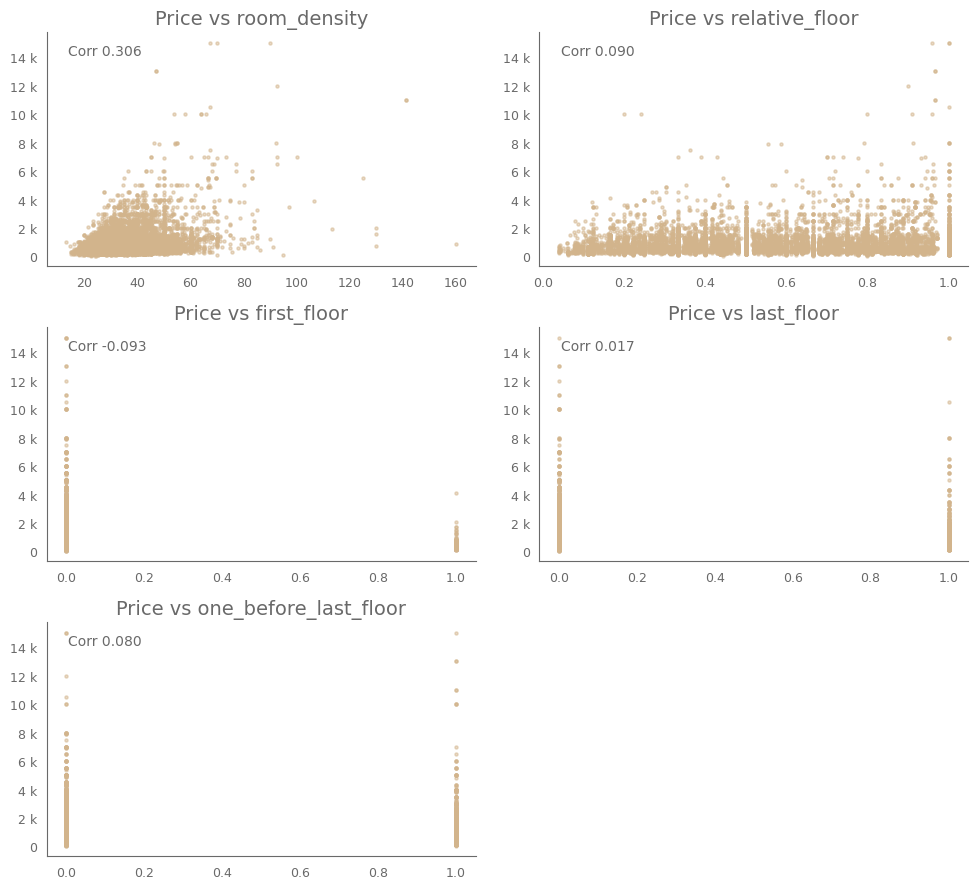

In [9]:
plot_numerical_vs_target(
    data,
    numerical_cols=['room_density', 'relative_floor',
                    'first_floor', 'last_floor',
                    'one_before_last_floor'],
    target_col='price',
    filter_iqr=False
)

## Categorical Feature Engineering

We extract and transform categorical features, including apartment characteristics, residential complexes, and neighborhoods.

### Extract Features from `features` Column

In [10]:
def safe_literal_eval(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return []

In [11]:
all_characteristics = set()

def extract_all_characteristics(row):
    for value in safe_literal_eval(row):
        all_characteristics.add(value.strip())

data['features'].map(extract_all_characteristics)
all_characteristics

{'Євроремонт',
 'Багаторівнева',
 'Бетонно монолітний',
 'Від будівельників (з обробкою)',
 'Від будівельників вільне планування',
 'Газоблок',
 'Дизайнерський ремонт',
 'Дореволюційний',
 'Задовільний стан',
 'Кухня-вітальня',
 'Незавершений ремонт',
 'Пентхаус',
 'Перша здача',
 'Потрібен капітальний ремонт',
 'Потрібен косметичний ремонт',
 'Роздільне',
 'Сталінка',
 'Стара панель',
 'Стара цегла',
 'Студія',
 'Суміжна',
 'Суміжно-роздільна',
 'Типова панель',
 'Українська панель',
 'Українська цегла',
 'Хороший стан',
 'Чудовий стан'}

In [12]:
len(all_characteristics)

27

In [13]:
feature_map = {
    'Євроремонт': 'eurorenovation',
    'Багаторівнева': 'multilevel',
    'Бетонно монолітний': 'concrete_monolithic',
    'Від будівельників (з обробкою)': 'from_builders_with_finishing',
    'Від будівельників вільне планування': 'from_builders_free_planning',
    'Газоблок': 'autoclaved_aerated_concrete',
    'Дизайнерський ремонт': 'designer_renovation',
    'Дореволюційний': 'pre_revolutionary',
    'Задовільний стан': 'satisfactory_condition',
    'Кухня-вітальня': 'kitchen_living_room',
    'Незавершений ремонт': 'repair_in_progress',
    'Пентхаус': 'penthouse',
    'Перша здача': 'first_rental',
    'Потрібен капітальний ремонт': 'needs_major_repairs',
    'Потрібен косметичний ремонт': 'needs_cosmetic_repairs',
    'Роздільне': 'separate',
    'Сталінка': 'stalinka',
    'Стара панель': 'old_panel',
    'Стара цегла': 'old_brick',
    'Студія': 'studio',
    'Суміжна': 'adjacent',
    'Суміжно-роздільна': 'adjacent_separate',
    'Типова панель': 'typical_panel',
    'Українська панель': 'ukrainian_panel',
    'Українська цегла': 'ukrainian_brick',
    'Хороший стан': 'good_condition',
    'Чудовий стан': 'excellent_condition',
}

In [14]:
for label, col_name in feature_map.items():
    data[col_name] = (data['features']
                      .map(lambda x: int(label in x)))

In [15]:
data.iloc[:, -27:]

,eurorenovation,multilevel,concrete_monolithic,from_builders_with_finishing,from_builders_free_planning,autoclaved_aerated_concrete,designer_renovation,pre_revolutionary,satisfactory_condition,kitchen_living_room,...,old_panel,old_brick,studio,adjacent,adjacent_separate,typical_panel,ukrainian_panel,ukrainian_brick,good_condition,excellent_condition
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9135,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9136,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9137,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
9138,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
for col in data.iloc[:, -26:].columns:
    print(data[col].value_counts(), '\n')

multilevel
0    9077
1      63
Name: count, dtype: int64 

concrete_monolithic
0    6191
1    2949
Name: count, dtype: int64 

from_builders_with_finishing
0    9136
1       4
Name: count, dtype: int64 

from_builders_free_planning
0    9137
1       3
Name: count, dtype: int64 

autoclaved_aerated_concrete
0    9050
1      90
Name: count, dtype: int64 

designer_renovation
0    6544
1    2596
Name: count, dtype: int64 

pre_revolutionary
0    8863
1     277
Name: count, dtype: int64 

satisfactory_condition
0    8932
1     208
Name: count, dtype: int64 

kitchen_living_room
0    8871
1     269
Name: count, dtype: int64 

repair_in_progress
0    9136
1       4
Name: count, dtype: int64 

penthouse
0    9104
1      36
Name: count, dtype: int64 

first_rental
0    8749
1     391
Name: count, dtype: int64 

needs_major_repairs
0    9139
1       1
Name: count, dtype: int64 

needs_cosmetic_repairs
0    9125
1      15
Name: count, dtype: int64 

separate
1    5546
0    3594
Name: count, dtyp

There are few appartments with such features as `needs_cosmetic_repairs`, `needs_major_repairs`, `repair_in_progress`, `from_builders_free_planning`, `from_builders_with_finishing`. Drop these columns.

In [17]:
data.drop(['needs_cosmetic_repairs',
           'needs_major_repairs',
           'repair_in_progress',
           'from_builders_free_planning',
           'from_builders_with_finishing'], axis=1, inplace=True)

And let's create features `brick` and `panel`.

In [18]:
brick_lst = ['old_brick', 'ukrainian_brick']
data['brick'] = data.apply(lambda x: int(any(x[brick_lst])), axis=1)
data['brick'].value_counts(dropna=False)

brick
0    7414
1    1726
Name: count, dtype: int64

In [19]:
panel_lst = ['old_panel', 'ukrainian_panel', 'typical_panel']
data['panel'] = data.apply(lambda x: int(any(x[panel_lst])), axis=1)
data['panel'].value_counts(dropna=False)

panel
0    8507
1     633
Name: count, dtype: int64

In [20]:
del data['features']

### Extract Attributes from `Attributes` Column

In [21]:
data.loc[~data['attributes'].isna(), 'attributes']

1       ['Посудомийна машина', 'Лічильники', 'Кондиціо...
3       ['Душова кабіна', 'Лічильники', 'Посуд', 'Прал...
4       ['Посудомийна машина', 'Лічильники', 'Кондиціо...
8       ['Душова кабіна', 'Кондиціонер', 'Посуд', 'Пра...
10      ['Душова кабіна', 'Лічильники', 'Кондиціонер',...
                              ...                        
9129    ['Посудомийна машина', 'Посуд', 'Мікрохвильовк...
9130    ['Посудомийна машина', 'Лічильники', 'Кондиціо...
9134    ['Посудомийна машина', 'Душова кабіна', 'Конди...
9136    ['Лічильники', 'Сигналізація', 'Кондиціонер', ...
9139    ['Посудомийна машина', 'Душова кабіна', 'Джаку...
Name: attributes, Length: 5501, dtype: object

In [22]:
all_attributes = set()

def extract_all_characteristics(row):
    for value in safe_literal_eval(row):
        if value == '': continue
        all_attributes.add(value.strip())

data.loc[~data['attributes'].isna(), 'attributes'].map(extract_all_characteristics)
all_attributes

{'DVD програвач',
 'Джакузі',
 'Душова кабіна',
 'Кабельне ТБ',
 'Камін',
 'Кондиціонер',
 'Ліжко',
 'Лічильники',
 'Мікрохвильовка',
 'Посуд',
 'Посудомийна машина',
 'Пральна машина',
 'Праска',
 'Сейф',
 'Сигналізація',
 'Супутникове ТБ',
 'Телевізор',
 'Фен',
 'Холодильник',
 'Шафа'}

In [23]:
len(all_attributes)

20

In [24]:
attribute_map  = {
    'DVD програвач': 'DVD_player',
    'Джакузі': 'jacuzzi',
    'Душова кабіна': 'shower_cabin',
    'Камін': 'fireplace',
    'Кондиціонер': 'air_conditioning',
    'Ліжко': 'bed',
    'Лічильники': 'counters',
    'Мікрохвильовка': 'microwave',
    'Посудомийна машина': 'dishwashers',
    'Пральна машина': 'washing_machine',
    'Праска': 'iron',
    'Сейф': 'safe',
    'Сигналізація': 'alarms',
    'Телевізор': 'TV',
    'Кабельне ТБ': 'cable_TV',
    'Супутникове ТБ': 'satellite_TV',
    'Фен': 'hair_dryer',
    'Холодильник': 'refrigerator',
    'Шафа': 'wardrobe',
}

In [25]:
for label, col_name in attribute_map.items():
    data[col_name] = (
        data.loc[~data['attributes'].isna(), 'attributes']
        .map(lambda x: int(label in x)))

In [26]:
data.iloc[:, -20:]

,panel,DVD_player,jacuzzi,shower_cabin,fireplace,air_conditioning,bed,counters,microwave,dishwashers,washing_machine,iron,safe,alarms,TV,cable_TV,satellite_TV,hair_dryer,refrigerator,wardrobe
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9135,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9136,0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
9137,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9138,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
for col in data.iloc[:, -20:].columns:
    print(data[col].value_counts(), '\n')

panel
0    8507
1     633
Name: count, dtype: int64 

DVD_player
0.0    5301
1.0     200
Name: count, dtype: int64 

jacuzzi
0.0    5115
1.0     386
Name: count, dtype: int64 

shower_cabin
0.0    3415
1.0    2086
Name: count, dtype: int64 

fireplace
0.0    5348
1.0     153
Name: count, dtype: int64 

air_conditioning
1.0    4196
0.0    1305
Name: count, dtype: int64 

bed
1.0    5057
0.0     444
Name: count, dtype: int64 

counters
1.0    4225
0.0    1276
Name: count, dtype: int64 

microwave
1.0    3468
0.0    2033
Name: count, dtype: int64 

dishwashers
0.0    3200
1.0    2301
Name: count, dtype: int64 

washing_machine
1.0    5304
0.0     197
Name: count, dtype: int64 

iron
0.0    3977
1.0    1524
Name: count, dtype: int64 

safe
0.0    5250
1.0     251
Name: count, dtype: int64 

alarms
0.0    4510
1.0     991
Name: count, dtype: int64 

TV
1.0    3908
0.0    1593
Name: count, dtype: int64 

cable_TV
0.0    3693
1.0    1808
Name: count, dtype: int64 

satellite_TV
0.0    5004
1.

In [28]:
del data['attributes']

### Residential and Neighborhood Groups

Keep only the most frequent residential complexes and neighbornhoods, group others as 'other'.

In [29]:
top_n = 20
top_residential = data['residential'].value_counts().nlargest(top_n).index
data['residential_top'] = data['residential'].where(
    data['residential'].isin(top_residential), 'other'
)

In [30]:
data['residential_top'].value_counts()

residential_top
other                        7650
ЖК Новопечерські Липки        253
ЖК Французький квартал 2      172
ЖК Нова Англія                 84
ЖК Park Avenue VIP             79
ЖК Зарічний                    78
ЖК Ярославів Град              72
ЖК Комфорт Таун                71
ЖК Central Park                70
ЖК Французький квартал         70
ЖК ЖМ Патріотика               68
ЖК Manhattan city              58
ЖК Варшавський Плюс            54
ЖК Tetris Hall                 51
ЖК Бульвар Фонтанів            50
ЖК Варшавський Мікрорайон      47
ЖК Файна Таун                  46
ЖК Златоустівський             44
ЖК LIKO-GRAD Perfect Town      41
ЖК Метрополіс                  41
ЖК Atlantic                    41
Name: count, dtype: int64

In [31]:
data['neighborhood_list'] = data['neighborhood'].apply(safe_literal_eval)

# Flatten all lists and count frequencies
all_neighborhoods = [item for sublist in data['neighborhood_list']
                     for item in sublist]
top_neighborhoods = set([
    x for x, _ in Counter(all_neighborhoods).most_common(top_n)
])

In [32]:
def get_main_neighborhood(neigh_list):
    for name in neigh_list:
        if name in top_neighborhoods:
            return name
    return 'Other'

In [33]:
data['neighborhood_top'] = (data['neighborhood_list']
                            .apply(get_main_neighborhood))

In [34]:
data['neighborhood_top'].value_counts()

neighborhood_top
Other                                    4603
ТЦ Ocean Plaza                            455
Юрковиця                                  410
Новопечерські липки                       345
Осокорки                                  326
Оболонь                                   286
Печерськ                                  259
Глушкова Академіка                        224
Солдатська слобідка                       219
Бессарабка                                205
Проспект Соборності                       204
Ботанічний сад ім. акад. О. В. Фоміна     201
Бусове поле                               201
Голосіїв                                  198
Афанасівський яр                          190
Старий Київ                               185
Стадіон Олімпійський                      169
Черепанова гора                           142
Охматдит                                  140
Куренівка                                 134
Чорна гора                                 44
Name: count, dtyp

## Geospatial Features

We add geospatial and district-based features, including clustering districts into price tiers.

### District Coordinates

In [35]:
data['district'].value_counts(dropna=False)

district
Печерський        2067
Шевченківський    1548
Голосіївський     1201
Дарницький        1142
Солом'янський      736
Дніпровський       663
Подільський        568
Оболонський        497
Святошинський      422
Деснянський        296
Name: count, dtype: int64

Add coordinates for `district`.

In [36]:
district_coords = pd.read_csv('../data/external/district_location.csv')

In [37]:
data = data.merge(district_coords, how='left', on='district')

In [38]:
data[['district', 'district_lat', 'district_lon']]

,district,district_lat,district_lon
0,Печерський,50.428611,30.553056
1,Печерський,50.428611,30.553056
2,Шевченківський,50.462500,30.461944
3,Дарницький,50.403333,30.704722
4,Дарницький,50.403333,30.704722
...,...,...,...
9135,Святошинський,50.468889,30.335000
9136,Печерський,50.428611,30.553056
9137,Солом'янський,50.420556,30.457778
9138,Печерський,50.428611,30.553056


### Cluster Districts into Price Tiers
We cluster districts into price tiers based on their average rent price.

In [39]:
# Calculate mean price per district
district_price = data.groupby('district')['price'].mean().sort_values()

# Assign tiers (3 clusters: low, mid, high)
n_tiers = 3
district_tiers = pd.qcut(
    district_price,
    q=n_tiers,
    labels=[f'tier_{i+1}' for i in range(n_tiers)])
district_tier_map = district_tiers.to_dict()
data['district_price_tier'] = data['district'].map(district_tier_map)

### Latitude/Longitude Imputation

In [40]:
data[['lat', 'lon']].isna().sum()

lat    108
lon    108
dtype: int64

Fill missing value in `lat` and `lon` using geoencoding by `address`.

In [41]:
data['address'].isna().sum()

0

In [42]:
data_temp = data.loc[data['lat'].isna(), ['address', 'district']]
data_temp

,address,district
252,"Лісківська вул., 18В",Деснянський
353,"Правди просп., 41Д",Подільський
551,"Зарічна вул., 3а",Дарницький
616,"Євгена Сверстюка вул. (Раскової Марини), 6д",Дніпровський
856,"Дністерська вул. (Двінська), 19",Дніпровський
...,...,...
8631,"Трускавецька вул., 8",Дарницький
8766,"Хмельницького Богдана вул., 30/10",Шевченківський
8827,"Братства тарасівців вул. (Декабристів), 9",Дарницький
8955,"Юрія Пасхаліна вул. (Ілліча), 17",Дарницький


In [43]:
def change_address(address):
    # delete the old street name in brackets
    if '(' in address:
        new_address = address[:address.find('(')-1] + address[address.find(')')+1:]
    else:
        new_address = address

    if 'бульв.' in new_address:
        new_address = new_address.replace(' бульв.', '')
        new_address = f"бульвар {new_address}, Київ"
    elif 'вул.' in new_address:
        new_address = new_address.replace(' вул.', '')
        new_address = f"вулиця {new_address}, Київ"
    elif 'просп.' in new_address:
        new_address = new_address.replace(' просп.', '')
        new_address = f"проспект {new_address}, Київ"
    else:
        new_address = f"{new_address}, Київ"

    return new_address

In [44]:
data_temp['location'] = (data_temp['address']
                         .apply(change_address)
                         .progress_apply(geocode))
data_temp

100%|██████████| 108/108 [02:08<00:00,  1.19s/it]


,address,district,location
252,"Лісківська вул., 18В",Деснянський,"(18-В, Лісківська вулиця, 21-й мікрорайон Вигу..."
353,"Правди просп., 41Д",Подільський,"(41-Д, проспект Європейського Союзу, Винограда..."
551,"Зарічна вул., 3а",Дарницький,"(3-А, Зарічна вулиця, ЖК «Зарічний», Дарницьки..."
616,"Євгена Сверстюка вул. (Раскової Марини), 6д",Дніпровський,"(Персей, 6-Д, вулиця Євгена Сверстюка, Селище ..."
856,"Дністерська вул. (Двінська), 19",Дніпровський,"(19, Дністерська вулиця, Стара Дарниця, Соцміс..."
...,...,...,...
8631,"Трускавецька вул., 8",Дарницький,"(8, Трускавецька вулиця, 11-й мікрорайон Позня..."
8766,"Хмельницького Богдана вул., 30/10",Шевченківський,"(30/10, вулиця Богдана Хмельницького, Святосла..."
8827,"Братства тарасівців вул. (Декабристів), 9",Дарницький,"(ХарьОк, 9-Е, вулиця Братства тарасівців, 10-й..."
8955,"Юрія Пасхаліна вул. (Ілліча), 17",Дарницький,"(17, вулиця Юрія Пасхаліна, Нова Дарниця, Дарн..."


In [45]:
data_temp['lat'] = (data_temp.apply(
    lambda x: (x['location'].latitude
               if (x['location']) and (x['district'].replace("'", "’")
               in str(x['location']))
               else None), axis=1
    ))

data_temp['lon'] = (data_temp.apply(
    lambda x: (x['location'].longitude
               if (x['location']) and (x['district'].replace("'", "’")
               in str(x['location']))
               else None), axis=1
    ))

data_temp

,address,district,location,lat,lon
252,"Лісківська вул., 18В",Деснянський,"(18-В, Лісківська вулиця, 21-й мікрорайон Вигу...",50.527214,30.598196
353,"Правди просп., 41Д",Подільський,"(41-Д, проспект Європейського Союзу, Винограда...",50.500975,30.427074
551,"Зарічна вул., 3а",Дарницький,"(3-А, Зарічна вулиця, ЖК «Зарічний», Дарницьки...",50.396762,30.600143
616,"Євгена Сверстюка вул. (Раскової Марини), 6д",Дніпровський,"(Персей, 6-Д, вулиця Євгена Сверстюка, Селище ...",50.446189,30.606131
856,"Дністерська вул. (Двінська), 19",Дніпровський,"(19, Дністерська вулиця, Стара Дарниця, Соцміс...",50.432623,30.637475
...,...,...,...,...,...
8631,"Трускавецька вул., 8",Дарницький,"(8, Трускавецька вулиця, 11-й мікрорайон Позня...",50.402764,30.610419
8766,"Хмельницького Богдана вул., 30/10",Шевченківський,"(30/10, вулиця Богдана Хмельницького, Святосла...",50.446710,30.511355
8827,"Братства тарасівців вул. (Декабристів), 9",Дарницький,"(ХарьОк, 9-Е, вулиця Братства тарасівців, 10-й...",50.403109,30.654356
8955,"Юрія Пасхаліна вул. (Ілліча), 17",Дарницький,"(17, вулиця Юрія Пасхаліна, Нова Дарниця, Дарн...",50.425686,30.651920


In [46]:
data = data.fillna(data_temp)

In [47]:
data['lat'].isna().sum()

16

Use transfrom method for fill missing value in `lat` and `lon` columns.

In [48]:
data['lat'] = data['lat'].fillna(data.groupby(['district'])['lat'].transform('median'))
data['lon'] = data['lon'].fillna(data.groupby(['district'])['lon'].transform('median'))

print(data['lat'].isna().sum(), data['lon'].isna().sum())

0 0


### Subway Line Feature

In [49]:
red_line = set([
    'Академмістечко', 'Житомирська', 'Святошин', 'Нивки',
    'Берестейська', 'Шулявська', 'Політехнічний інститут',
    'Вокзальна', 'Університет', 'Театральна', 'Хрещатик',
    'Арсенальна', 'Дніпро', 'Гідропарк', 'Лівобережна',
    'Дарниця', 'Чернігівська', 'Лісова'
])
green_line = set([
    'Сирець', 'Дорогожичі', 'Лук\'янівська', 'Золоті Ворота',
    'Палац Спорту', 'Кловська', 'Печерська', 'Звіринецька',
    'Видубичі', 'Славутич', 'Осокорки', 'Позняки', 'Харківська',
    'Вирлиця', 'Бориспільська', 'Червоний хутір'
])
blue_line = set([
    'Героїв Дніпра', 'Мінська', 'Оболонь', 'Почайна',
    'Тараса Шевченка', 'Контрактова площа', 'Поштова площа',
    'Майдан Незалежності', 'Площа Українських Героїв', 'Олімпійська',
    'Палац Україна', 'Либідська', 'Деміївська', 'Голосіївська',
    'Васильківська', 'Виставковий центр', 'Іподром', 'Теремки'
])

def get_subway_line(station):
    if station in red_line: return 'red'
    if station in green_line: return 'green'
    if station in blue_line: return 'blue'
    return np.nan

data['subway_line'] = data['subway'].apply(get_subway_line)

### Subway Location

In [50]:
df_subway_location = pd.read_csv('../data/external/subway_location.csv')

In [51]:
data = data.merge(df_subway_location, how='left', on='subway')
data[['subway', 'subway_lat', 'subway_lon']]

,subway,subway_lat,subway_lon
0,Звіринецька,50.417359,30.542823
1,Кловська,50.437062,30.529128
2,Лук'янівська,50.462176,30.480570
3,NaN,NaN,NaN
4,Славутич,50.394261,30.602284
...,...,...,...
9135,NaN,NaN,NaN
9136,Звіринецька,50.417359,30.542823
9137,NaN,NaN,NaN
9138,Палац Україна,50.421416,30.518189


### Distance to Subway and City Center

#### Min Distance to Subway

In [52]:
def get_min_dist_to_subway(adr_loc, df_subway_location):
    df_subway_location['lat_lon'] = list(zip(df_subway_location['subway_lat'],
                                             df_subway_location['subway_lon']))

    dists = df_subway_location['lat_lon'].apply(lambda x: geodesic(adr_loc, x).kilometers)
    return min(dists)

data['min_dist_to_subway'] = data.progress_apply(
    lambda x: get_min_dist_to_subway((x['lat'], x['lon']),
                                     df_subway_location), axis=1)


100%|██████████| 9140/9140 [01:38<00:00, 92.77it/s] 


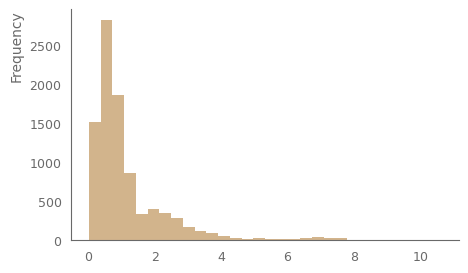

In [53]:
data['min_dist_to_subway'].plot(kind='hist', bins=30, color=COLOR_PLOT)
plt.show()

#### Distance to Kyiv center

In [54]:
centre_loc = (50.450555, 30.5206892) # geo of Kyiv centre
centre_loc

(50.450555, 30.5206892)

In [55]:
def get_dist_to_center(adr_loc):
    return geodesic(adr_loc, centre_loc).kilometers

In [56]:
data['dist_to_center'] = (data.progress_apply(
    lambda x: get_dist_to_center((x['lat'], x['lon'])), axis=1))

100%|██████████| 9140/9140 [00:02<00:00, 4256.61it/s]


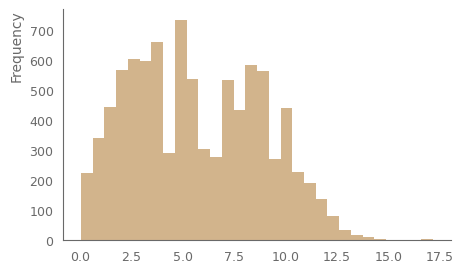

In [57]:
data['dist_to_center'].plot(kind='hist', bins=30, color=COLOR_PLOT)
plt.show()

## Text Feature Extraction

We extract features from the `description` and `detail` columns, such as amenities, pet/children policy, and view.

### Update Attributes

In [58]:
attr_dict = {
    'DVD_player': ['DVD'],
    'jacuzzi': ['джакуз'],
    'shower_cabin': ['душова', 'душев'],
    'fireplace': ['камін', 'камин'],
    'air_conditioning': ['кондиц'],
    'bed': ['ліжк', 'кроват'],
    'counters': ['лічильник', 'счетчик'],
    'microwave': ['мікрохвил', 'микроволн', 'микрохвил'],
    'dishwashers': ['посудомий', 'посудомо'],
    'washing_machine': ['пральн', 'стиральн'],
    'iron': ['праск', 'утюг'],
    'safe' : ['сейф'],
    'alarms': ['сигналізац', 'сигнализац'],
    'TV': ['телевізор', 'тв', 'телевизор'],
    'cable_TV': ['кабельн'],
    'satellite_TV': ['супутникове', 'спутников'],
    'hair_dryer': ['фен'],
    'refrigerator': ['холодильник'],
    'wardrobe': ['шаф', 'шкаф'],
}

In [59]:
for col_name, attr_list in attr_dict.items():
    data.loc[data[col_name] != 1, col_name] = (
        data
        .loc[data[col_name] != 1, 'description']
        .str.lower()
        .str.contains("|".join(attr_list), regex=True)
        .astype(int)
    )

In [60]:
for col in attr_dict.keys():
    print(data[col].value_counts(dropna=False), "\n")

DVD_player
0.0    8940
1.0     200
Name: count, dtype: int64 

jacuzzi
0.0    8666
1.0     474
Name: count, dtype: int64 

shower_cabin
0.0    6759
1.0    2381
Name: count, dtype: int64 

fireplace
0.0    8809
1.0     331
Name: count, dtype: int64 

air_conditioning
1.0    5668
0.0    3472
Name: count, dtype: int64 

bed
1.0    5823
0.0    3317
Name: count, dtype: int64 

counters
1.0    4897
0.0    4243
Name: count, dtype: int64 

microwave
0.0    4967
1.0    4173
Name: count, dtype: int64 

dishwashers
0.0    5855
1.0    3285
Name: count, dtype: int64 

washing_machine
1.0    6671
0.0    2469
Name: count, dtype: int64 

iron
0.0    7459
1.0    1681
Name: count, dtype: int64 

safe
0.0    8821
1.0     319
Name: count, dtype: int64 

alarms
0.0    7900
1.0    1240
Name: count, dtype: int64 

TV
1.0    5800
0.0    3340
Name: count, dtype: int64 

cable_TV
0.0    7215
1.0    1925
Name: count, dtype: int64 

satellite_TV
0.0    8617
1.0     523
Name: count, dtype: int64 

hair_dryer
0.0  

### Update Features

In [61]:
feature_dict = {
    'designer_renovation': ['дизайнерс', 'дизайном', 'авторс'],
    'penthouse': ['пентхаус'],
    'first_rental': ['перша здача', 'первая сдача',
                     'сдается впервые', 'здається вперше',
                     'перша оренда'],
}

In [62]:
for col in feature_dict.keys():
    print(data[col].value_counts(dropna=False), "\n")

designer_renovation
0    6544
1    2596
Name: count, dtype: int64 

penthouse
0    9104
1      36
Name: count, dtype: int64 

first_rental
0    8749
1     391
Name: count, dtype: int64 



In [63]:
for col_name, feat_list in feature_dict.items():
    data.loc[data[col_name] != 1, col_name] = (
        data
        .loc[data[col_name] != 1, 'description']
        .str.lower()
        .str.contains("|".join(feat_list), regex=True)
        .astype(int)
    )

In [64]:
for col in feature_dict.keys():
    print(data[col].value_counts(dropna=False), "\n")

designer_renovation
0    5944
1    3196
Name: count, dtype: int64 

penthouse
0    9038
1     102
Name: count, dtype: int64 

first_rental
0    8120
1    1020
Name: count, dtype: int64 



### Multilevel apartments

In [65]:
regex_list = [
    r'[-\s]?уровнев(?:ая|ой|ый|ую|ым)?\s(?:квартир[аыуе]|пентхаус|[ом])',
    r'рівнева(?!\s+(?:підсвітка|система|кровать|дитяча|спальня|канатна))',
    r'[-\s]?рівневий пентхаус'
]

for regex in regex_list:
    data.loc[data['multilevel'] != 1, 'multilevel'] =  (
        data
        .loc[data['multilevel'] != 1, 'description']
        .str.lower()
        .str.contains(regex, regex=True)
        .astype(int)
    )

In [66]:
data['multilevel'].value_counts()

multilevel
0    8992
1     148
Name: count, dtype: int64

### Amenities (parking, security, etc.)
Create additional features, such as `parking`, `security`, `boiler`, `video_monitoring`, `dryer_machine`

In [67]:
feature_dict = {
    'parking': ['паркінг', 'паркинг'],
    'security': ['охорон', 'охран'],
    'boiler': ['бойлер'],
    'video_monitoring': ['відеоспостереження', 'видеонаблюдени'],
    'dryer_machine': ['сушильн',],
    'balcony': ['балкон', 'лоджія', 'лоджия'],
    'elevator': ['ліфт', 'лифт'],
    'terrace': ['террас', 'терас'],
    'office_room': ['кабінет', 'кабинет'],
    'laundry': ['прачечн', 'постирочн', 'пральня']
}

In [68]:
for col_name, feat_list in feature_dict.items():
    data[col_name] = (data['description']
                      .str.lower()
                      .str.contains("|".join(feat_list), regex=True)
                      .astype(int))

In [69]:
for col in feature_dict.keys():
    print(data[col].value_counts(dropna=False), '\n')

parking
0    7084
1    2056
Name: count, dtype: int64 

security
0    7042
1    2098
Name: count, dtype: int64 

boiler
0    6068
1    3072
Name: count, dtype: int64 

video_monitoring
0    8156
1     984
Name: count, dtype: int64 

dryer_machine
0    8746
1     394
Name: count, dtype: int64 

balcony
0    6313
1    2827
Name: count, dtype: int64 

elevator
0    7555
1    1585
Name: count, dtype: int64 

terrace
0    8786
1     354
Name: count, dtype: int64 

office_room
0    8459
1     681
Name: count, dtype: int64 

laundry
0    9008
1     132
Name: count, dtype: int64 



### Pet/Children Policy

In [70]:
policy_dict = {
    'no_pets': ['без тварин', 'без животных', 'без домашніх',
                'без собак', 'без котів', 'без кошек',
                r'без дітей\s+[а-я]*\s+тварин', 'без детей и животн'],
    'children_allowed': ['з дітьми', 'с детьми'],
    'no_children': ['без дітей', 'без детей'],
}

In [71]:
for col_name, feat_list in policy_dict.items():
    data[col_name] = (data['description']
                      .str.lower()
                      .str.contains("|".join(feat_list), regex=True)
                      .astype(int))

In [72]:
for col in policy_dict.keys():
    print(data[col].value_counts(dropna=False), '\n')

no_pets
0    8344
1     796
Name: count, dtype: int64 

children_allowed
0    8936
1     204
Name: count, dtype: int64 

no_children
0    9001
1     139
Name: count, dtype: int64 



### View

In [73]:
view_dict = {
    'has_view': [
        'вид',
        'вигляд',
        r'панорам(?:а|ны[ей]\s+(?:апартамент|вид))',
    ]
}

for col_name, feat_list in view_dict.items():
    data[col_name] = (data['description']
                      .str.lower()
                      .str.contains("|".join(feat_list), regex=True)
                      .astype(int))

In [74]:
data['has_view'].value_counts()

has_view
0    6401
1    2739
Name: count, dtype: int64

### Building Amenities

In [75]:
amenity_dict = {
    'has_pool': ['басейн', 'бассейн'],
    'has_gym': ['спортзал', 'фітнес', 'fitness'],
    'has_concierge': ['консьєрж', 'консьерж'],
    'has_playground': ['дитячий майданчик', 'детская площадка'],
    'has_parking': ['паркінг', 'паркинг'],
}

for col_name, feat_list in amenity_dict.items():
    data[col_name] = (data['description']
                      .str.lower()
                      .str.contains("|".join(feat_list), regex=True)
                      .astype(int))


In [76]:
for col in amenity_dict.keys():
    print(data[col].value_counts(dropna=False), '\n')

has_pool
0    8780
1     360
Name: count, dtype: int64 

has_gym
0    8581
1     559
Name: count, dtype: int64 

has_concierge
0    8080
1    1060
Name: count, dtype: int64 

has_playground
0    8790
1     350
Name: count, dtype: int64 

has_parking
0    7084
1    2056
Name: count, dtype: int64 



## Save Processed Data

We save the processed dataset for use in modeling.

In [ ]:
data.drop(['coordinates',
           'address',
           'region',
           'footage',
           'neighborhood_list',
           'neighborhood_1',
           'neighborhood_2',
           'neighborhood_3',
           'neighborhood_4',
           'neighborhood_5'
], axis=1, inplace=True)


In [82]:
data.shape

(9140, 97)

In [83]:
data.to_csv('../data/processed/train_fe.csv', index=False)

## Conclusion

We engineered a variety of features, including binned/capped numerical features, grouped categorical features, geospatial and district-based features, and extracted information from text. These features will be used in subsequent modeling steps to improve prediction accuracy.